In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
clean_data = pd.read_csv("cleaned_sales.csv")

In [9]:
clean_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-12-06,NaN,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-11-10,NaN,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-11-10,NaN,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [10]:
clean_data.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,NaN,NaN,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,2016-12-01,NaN,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,2016-12-01,NaN,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,2016-12-01,NaN,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,2016-12-01,NaN,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [11]:
clean_data.shape

(9800, 18)

In [12]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     3959 non-null   str    
 3   Ship Date      3815 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9800 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [13]:
clean_data.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9800.000000,9800.000000
mean,4900.500000,55276.498571,230.769059
std,2829.160653,32023.374393,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [15]:
total_sales = clean_data["Sales"].sum()

print(f"Total Sales : {total_sales:.2f}")

Total Sales : 2261536.78


In [18]:
total_orders = clean_data["Order ID"].nunique()

print(f"Total Orders: {total_orders}")

Total Orders: 4922


In [19]:
total_customers = clean_data["Customer ID"].nunique()

print(f"Total Customers: {total_customers}")

Total Customers: 793


In [20]:
average_order_value = total_sales / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 459.48


In [24]:
category_sales = (
    clean_data.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
).round(2)

category_sales

Category
Technology         827455.87
Furniture          728658.58
Office Supplies    705422.33
Name: Sales, dtype: float64

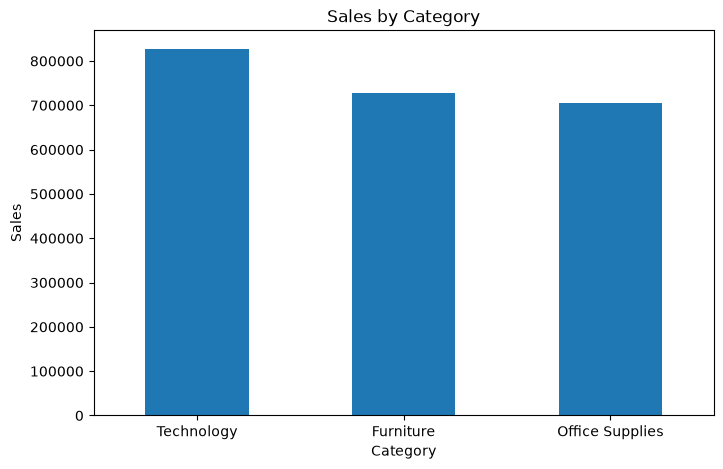

In [25]:
category_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [29]:
subcategory_sales = (
    clean_data.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_sales

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

In [30]:
subcategory_sales.head(10)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Name: Sales, dtype: float64

In [32]:
region_sales = (
    clean_data.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
).round(2)

region_sales

Region
West       710219.68
East       669518.73
Central    492646.91
South      389151.46
Name: Sales, dtype: float64

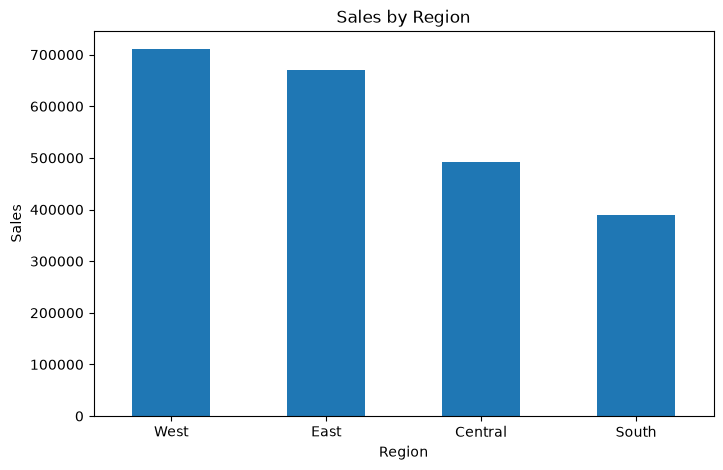

In [33]:
region_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [36]:
top_products = (
    clean_data.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
).round(2)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.82
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.38
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.48
HON 5400 Series Task Chairs for Big and Tall                                   21870.58
GBC DocuBind TL300 Electric Binding System                                     19823.48
GBC Ibimaster 500 Manual ProClick Binding System                               19024.50
Hewlett Packard LaserJet 3310 Copier                                           18839.69
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.90
GBC DocuBind P400 Electric Binding System                                      17965.07
High Speed Automatic Electric Letter Opener                                    17030.31
Name: Sales, dtype: float64

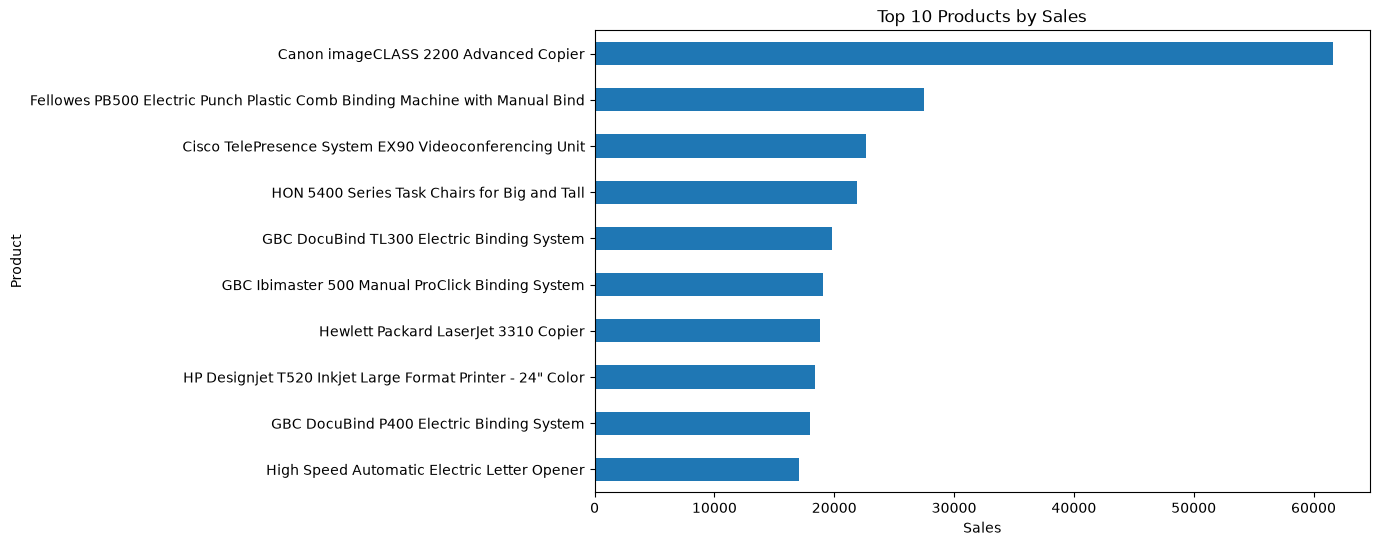

In [37]:
top_products.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

In [40]:
top_customers = (
    clean_data.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
).round(2)

top_customers

Customer Name
Sean Miller           25043.05
Tamara Chand          19052.22
Raymond Buch          15117.34
Tom Ashbrook          14595.62
Adrian Barton         14473.57
Ken Lonsdale          14175.23
Sanjit Chand          14142.33
Hunter Lopez          12873.30
Sanjit Engle          12209.44
Christopher Conant    12129.07
Name: Sales, dtype: float64

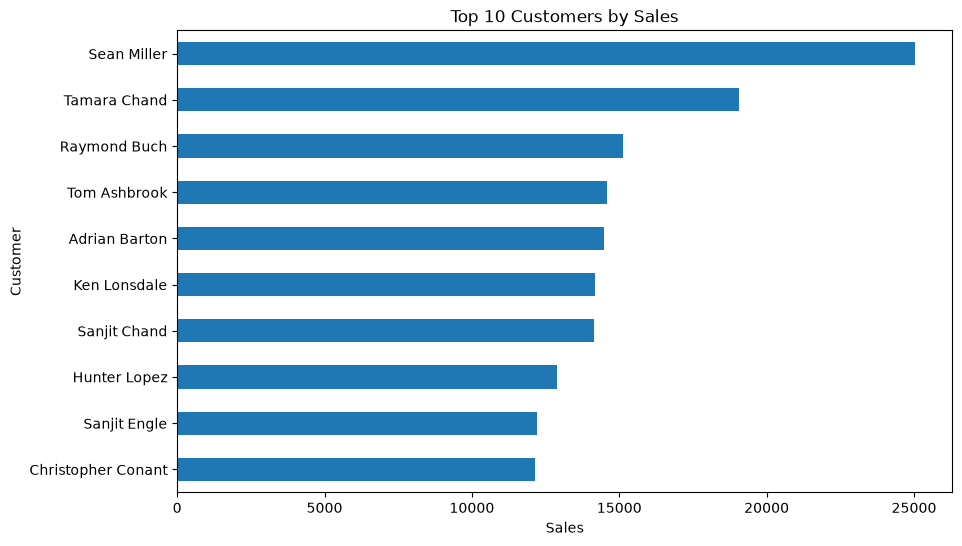

In [41]:
top_customers.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")
plt.show()

In [42]:
# Monthly Sales Analysis :-

clean_data["Order Date"] = pd.to_datetime(clean_data["Order Date"])

In [45]:
monthly_sales = (
    clean_data.groupby(clean_data["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
).round(2)

monthly_sales

Order Date
2015-01    19546.16
2015-02    11678.99
2015-03     6716.04
2015-04    12455.48
2015-05    15165.05
2015-06    11884.17
2015-07    10075.74
2015-08    26797.76
2015-09    17158.93
2015-10    10112.64
2015-11    18349.76
2015-12    17045.84
2016-01    17701.69
2016-02    13018.32
2016-03    12207.41
2016-04    11963.70
2016-05    10483.48
2016-06    13026.67
2016-07    10706.72
2016-08    22782.58
2016-09    16484.90
2016-10    12293.04
2016-11    12139.04
2016-12     9761.33
2017-01    26342.54
2017-02    42967.92
2017-03    25982.29
2017-04    19472.16
2017-05    22649.39
2017-06    14050.14
2017-07    16501.01
2017-08    24156.32
2017-09     9789.66
2017-10    22599.78
2017-11    20378.24
2017-12    21365.15
2018-01    27367.59
2018-02    36285.94
2018-03    26882.95
2018-04    21203.61
2018-05    15979.16
2018-06    12138.16
2018-07    25110.48
2018-08    26823.69
2018-09    23148.87
2018-10    17558.32
2018-11    17407.27
2018-12    16647.04
Freq: M, Name: Sales, dtype: 

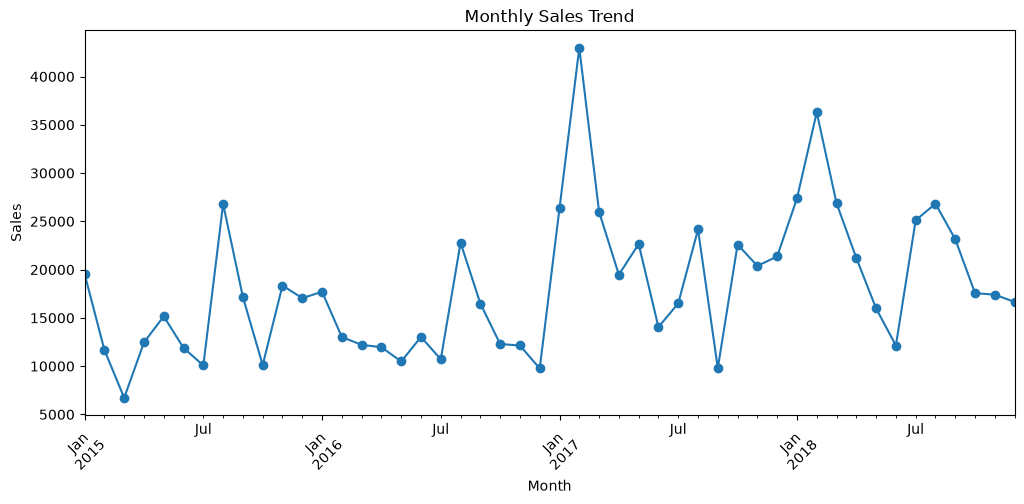

In [46]:
monthly_sales.plot(
    kind="line",
    figsize=(12,5),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [48]:
yearly_sales = (
    clean_data.groupby(clean_data["Order Date"].dt.year)["Sales"]
    .sum()
).round(2)

yearly_sales

Order Date
2015.0    176986.59
2016.0    162568.86
2017.0    266254.60
2018.0    266553.07
Name: Sales, dtype: float64

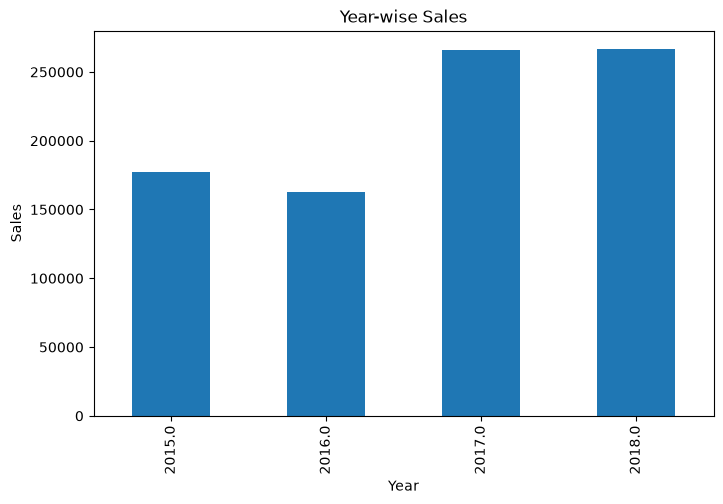

In [50]:
yearly_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

In [55]:
shipmode_sales = (
    clean_data.groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
).round(2)

shipmode_sales

Ship Mode
Standard Class    1340831.31
Second Class       449914.18
First Class        345572.26
Same Day           125219.04
Name: Sales, dtype: float64

In [57]:
segment_sales = (
    clean_data.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
).round(2)

segment_sales

Segment
Consumer       1148060.53
Corporate       688494.07
Home Office     424982.18
Name: Sales, dtype: float64

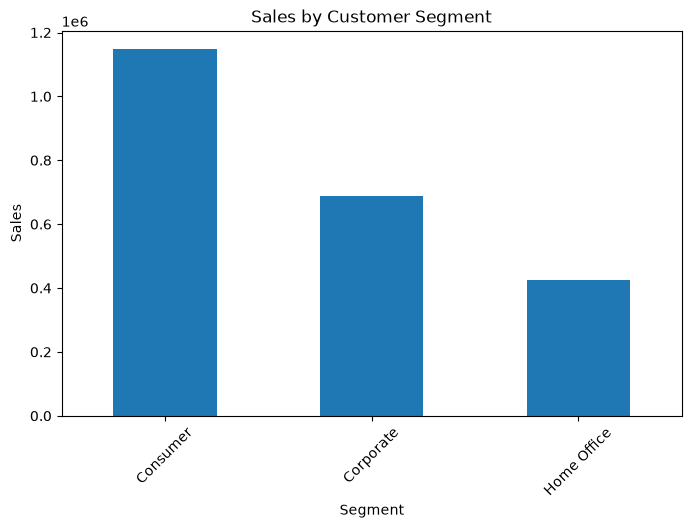

In [61]:
segment_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [62]:
print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

print("\nTop Category:")
print(category_sales.head(1))

print("\nTop Region:")
print(region_sales.head(1))

print("\nTop Product:")
print(top_products.head(1))

print("\nTop Customer:")
print(top_customers.head(1))

Total Sales: 2261536.7827
Total Orders: 4922
Total Customers: 793

Top Category:
Category
Technology    827455.87
Name: Sales, dtype: float64

Top Region:
Region
West    710219.68
Name: Sales, dtype: float64

Top Product:
Product Name
Canon imageCLASS 2200 Advanced Copier    61599.82
Name: Sales, dtype: float64

Top Customer:
Customer Name
Sean Miller    25043.05
Name: Sales, dtype: float64
